### EX: Manual Edge Detection

In this exercise, we will bypass deep learning entirely and manually apply a classic convolution filter (the Sobel filter) to a simulated satellite image to see exactly how spatial math detects infrastructure.

* **Generate Data:** Create a 2D numpy array simulating a dark jungle with a bright, vertical concrete runway.

* **Define Kernels:** Manually define a Vertical Sobel filter and a Horizontal Sobel filter.

* **Convolve:** Slide the filters over the image using SciPy.

* **Visualize:** Observe how the vertical filter highlights the runway edges, while the horizontal filter ignores them.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

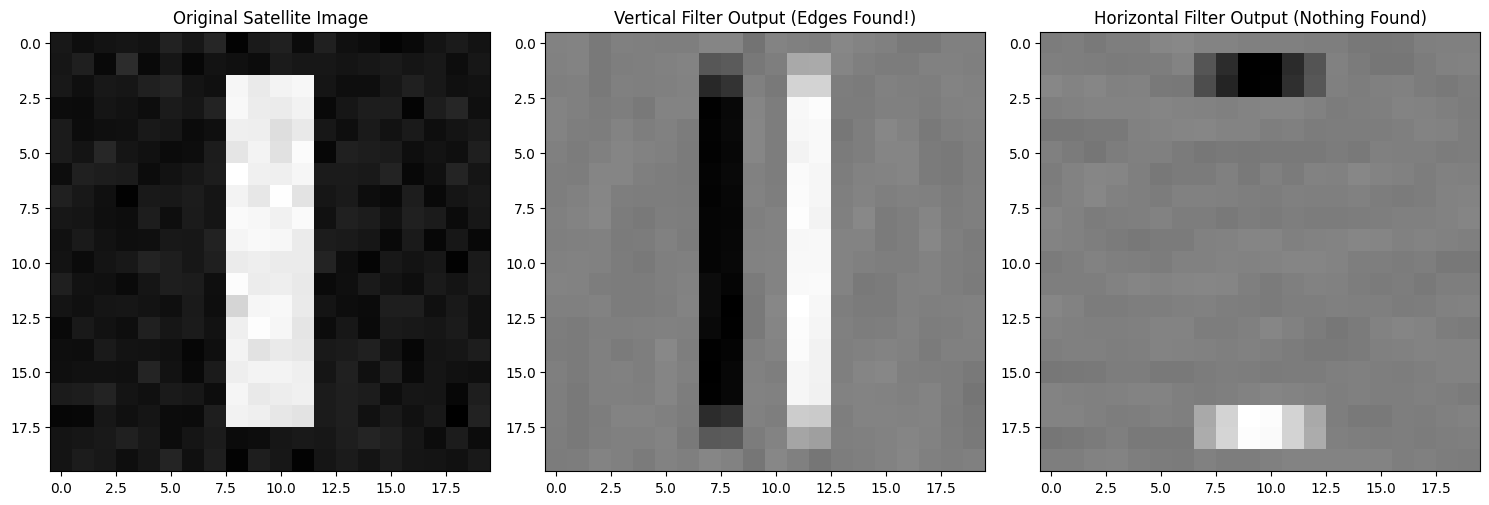

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# 1. Simulate Satellite Imagery (Dark background, bright vertical runway)
image = np.zeros((20, 20))
image[2:18, 8:12] = 255 # Create a bright vertical strip (runway)
image += np.random.normal(0, 10, (20, 20)) # Add sensor noise

# 2. Define Convolutional Kernels (Sobel Filters)
# Vertical Edge Detector
kernel_vertical = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])

# Horizontal Edge Detector
kernel_horizontal = np.array([[-1, -1, -1],
                              [ 0,  0,  0],
                              [ 1,  1,  1]])

# 3. Apply the Convolution Operation
output_vertical = convolve(image, kernel_vertical)
output_horizontal = convolve(image, kernel_horizontal)

# 4. Visualize the Results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Satellite Image')

axes[1].imshow(output_vertical, cmap='gray')
axes[1].set_title('Vertical Filter Output (Edges Found!)')

axes[2].imshow(output_horizontal, cmap='gray')
axes[2].set_title('Horizontal Filter Output (Nothing Found)')

plt.tight_layout()
plt.show()


### Interpreting the Results

Look at the matrices. The `kernel_vertical` has negative numbers on the left and positive numbers on the right. As it slides across the image, if it hits a patch of solid black jungle, the negatives and positives cancel out to zero (black). But when the filter straddles the dark jungle and the bright runway, the math results in a massive positive spike (white).

This is how an AI "sees". Instead of hand-coding these Sobel filters like we just did, a CNN automatically *learns* the optimal numbers to put inside these filters during training.